# Part 1: Feature Engineering & Selection

This notebook implements the Feature Engineering pipeline for predicting the Remaining Useful Life (RUL) of turbofan engines using the NASA C-MAPSS FD002 dataset. 
To prevent **Data Leakage** while accounting for **Multi-Regime Operating Conditions** (6 regimes), we:
1. **Operational Regime Clustering**: Group operating settings into 6 distinct regimes using KMeans.
2. **Regime-Specific Z-score Normalization**: Standardize the 13 active sensors within each regime to remove operational offsets.
3. **Causal Temporal Features**: Generate rolling averages, rolling standard deviations, rolling slopes, and cumulative stress (Cycle) without using future info.
4. **Feature Selection**: Apply correlation filters and tree-based importance rankings to reduce multicollinearity.

In [1]:
# Setup and library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

# Configure visualization styles
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Define paths
DATA_DIR = r"../data"
FIGURE_DIR = r"../figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIGURE_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

## 1.1 Load Cleaned Data

We load the smoothed features from Assignment 1.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "SmartFactory_FD002_cleaned.csv"))
print(f"Raw Cleaned Shape: {df.shape}")
df.head()

Raw Cleaned Shape: (53759, 48)


,Engine_ID,Cycle,OpSetting1,OpSetting2,OpSetting3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12_smooth,Sensor_13_smooth,Sensor_14_smooth,Sensor_15_smooth,Sensor_16_smooth,Sensor_17_smooth,Sensor_18_smooth,Sensor_19_smooth,Sensor_20_smooth,Sensor_21_smooth
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.060000,2387.720000,8048.560000,9.346100,0.02,334.000000,2223.000000,100.000000,14.730000,8.80710
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,156.740000,2387.690000,8060.430000,9.361750,0.02,332.000000,2217.500000,100.000000,12.570000,7.53680
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,159.233333,2267.803333,7995.243333,9.872533,0.02,324.333333,2116.666667,94.976667,13.073333,7.91530
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,152.105000,2297.755000,8013.597500,9.742600,0.02,325.500000,2140.500000,96.232500,12.452500,7.55400
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,154.546000,2243.804000,7983.124000,9.973340,0.02,322.200000,2095.400000,93.972000,12.788000,7.74892


## 1.2 Multi-Regime Normalization & Feature Generation

We identify active sensors, perform regime clustering, and build causal features.

In [3]:
# Define active sensors showing degradation
degrad_sensors = ['Sensor_2_smooth', 'Sensor_3_smooth', 'Sensor_4_smooth', 'Sensor_7_smooth', 
                  'Sensor_8_smooth', 'Sensor_11_smooth', 'Sensor_12_smooth', 'Sensor_13_smooth', 
                  'Sensor_14_smooth', 'Sensor_15_smooth', 'Sensor_17_smooth', 'Sensor_20_smooth', 
                  'Sensor_21_smooth']

# 1. Identify train split engines to fit K-Means (seed 42, split 0.8) to prevent future regime leakage
unique_engines = df['Engine_ID'].unique()
import numpy as np
np.random.seed(42)
np.random.shuffle(unique_engines)
split_idx = int(len(unique_engines) * 0.8)
train_engines = unique_engines[:split_idx]

# Fit KMeans strictly on train partition settings
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df[df['Engine_ID'].isin(train_engines)][['OpSetting1', 'OpSetting2', 'OpSetting3']])

# Predict on all data (causal, no leakage of regime centers from test set)
df['regime'] = kmeans.predict(df[['OpSetting1', 'OpSetting2', 'OpSetting3']])

# 2. Z-score normalization per regime (prevents mode variation)
for s in degrad_sensors:
    mean_val = df.groupby('regime')[s].transform('mean')
    std_val = df.groupby('regime')[s].transform('std')
    df[f'{s}_regime_norm'] = (df[s] - mean_val) / (std_val + 1e-5)

# 3. Time-window rolling features of normalized sensors
norm_sensors = [f'{s}_regime_norm' for s in degrad_sensors]
for s in norm_sensors:
    # Rolling mean (15 cycles)
    df[f'{s}_roll15_mean'] = df.groupby('Engine_ID')[s].transform(lambda x: x.rolling(15, min_periods=1).mean())
    # Rolling std (15 cycles)
    df[f'{s}_roll15_std'] = df.groupby('Engine_ID')[s].transform(lambda x: x.rolling(15, min_periods=1).std().fillna(0))
    # Rolling slope (5 cycles)
    df[f'{s}_slope5'] = df.groupby('Engine_ID')[s].transform(lambda x: x.rolling(5, min_periods=2).apply(
        lambda y: np.polyfit(np.arange(len(y)), y, 1)[0] if len(y) > 1 else 0.0, raw=True
    ).fillna(0))

# 4. Causal stress feature (cumulative cycles run - not leaked!)
df['cumulative_cycles'] = df['Cycle']

# 5. Physical cross interaction features on normalized values
df['S11_x_S12_norm'] = df['Sensor_11_smooth_regime_norm'] * df['Sensor_12_smooth_regime_norm']
df['S4_div_S11_norm'] = df['Sensor_4_smooth_regime_norm'] / (df['Sensor_11_smooth_regime_norm'].abs() + 1e-5)

# Piece-wise linear target RUL
df['RUL_capped'] = df['RUL'].clip(upper=125)

# Handle NaNs caused by rolling slope via backfill
df = df.bfill()
print("Finished creating 43 causal features.")


Finished creating 43 causal features.


C:\Users\21779\AppData\Local\Temp\ipykernel_37028\1859471517.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{s}_slope5'] = df.groupby('Engine_ID')[s].transform(lambda x: x.rolling(5, min_periods=2).apply(
C:\Users\21779\AppData\Local\Temp\ipykernel_37028\1859471517.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cumulative_cycles'] = df['Cycle']
C:\Users\21779\AppData\Local\Temp\ipykernel_37028\1859471517.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

## 1.3 Feature Selection: Multicollinearity Filter

We inspect mutual correlations and eliminate redundant features with correlation $> 0.95$.

In [4]:
engineered_features = [c for c in df.columns if c.endswith('_roll15_mean') or c.endswith('_roll15_std') or c.endswith('_slope5') or c in ['cumulative_cycles', 'S11_x_S12_norm', 'S4_div_S11_norm']]

# Multicollinearity filter (threshold = 0.95)
corr_matrix = df[engineered_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Dropped features due to multicollinearity: {to_drop}")

selected_features = [f for f in engineered_features if f not in to_drop]
print(f"Final Selected Features ({len(selected_features)}): {selected_features}")

Dropped features due to multicollinearity: ['Sensor_3_smooth_regime_norm_roll15_mean', 'Sensor_3_smooth_regime_norm_roll15_std', 'Sensor_3_smooth_regime_norm_slope5', 'Sensor_4_smooth_regime_norm_roll15_mean', 'Sensor_4_smooth_regime_norm_roll15_std', 'Sensor_4_smooth_regime_norm_slope5', 'Sensor_7_smooth_regime_norm_roll15_mean', 'Sensor_7_smooth_regime_norm_slope5', 'Sensor_11_smooth_regime_norm_roll15_mean', 'Sensor_11_smooth_regime_norm_slope5', 'Sensor_12_smooth_regime_norm_roll15_mean', 'Sensor_12_smooth_regime_norm_roll15_std', 'Sensor_12_smooth_regime_norm_slope5', 'Sensor_15_smooth_regime_norm_roll15_mean', 'Sensor_15_smooth_regime_norm_roll15_std', 'Sensor_15_smooth_regime_norm_slope5', 'Sensor_17_smooth_regime_norm_roll15_mean', 'Sensor_17_smooth_regime_norm_roll15_std', 'Sensor_17_smooth_regime_norm_slope5', 'Sensor_20_smooth_regime_norm_roll15_mean', 'Sensor_20_smooth_regime_norm_roll15_std', 'Sensor_20_smooth_regime_norm_slope5', 'Sensor_21_smooth_regime_norm_roll15_mean'

## 1.4 Feature Importance Analysis

We fit a Random Forest Regressor on the selected features to identify top predictive features.

C:\Users\21779\AppData\Local\Temp\ipykernel_37028\2418630769.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=ax, palette="viridis")


Saved: ../figures\Feature_Importance.png


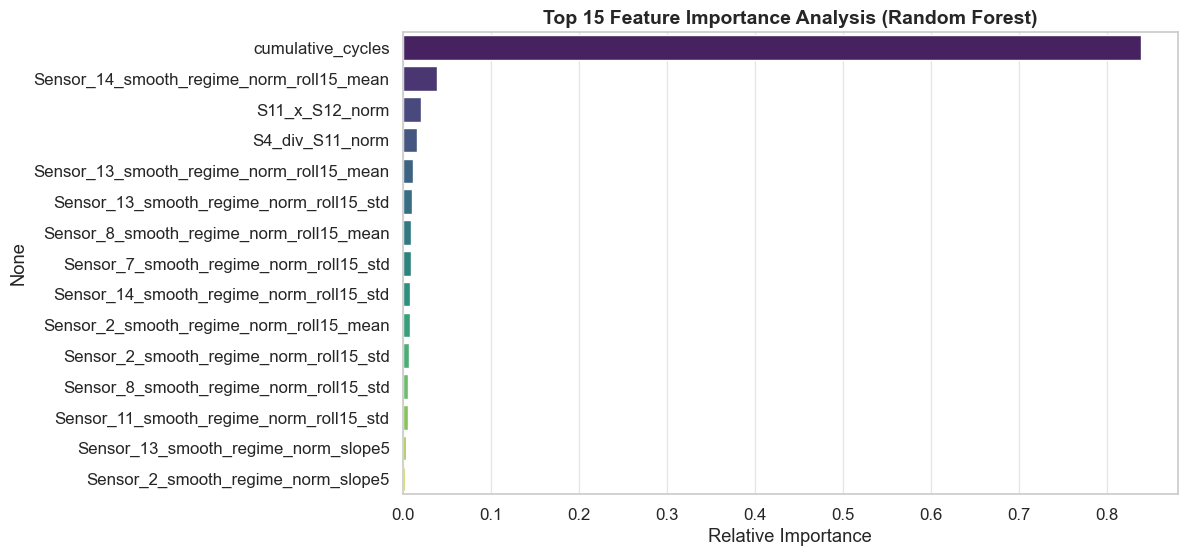

In [5]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[selected_features] = scaler.fit_transform(df[selected_features])

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(df_scaled[selected_features], df_scaled['RUL_capped'])
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=ax, palette="viridis")
ax.set_title("Top 15 Feature Importance Analysis (Random Forest)", fontsize=14, fontweight='bold')
ax.set_xlabel("Relative Importance")
save_fig(fig, "Feature_Importance.png")
plt.show()

## 1.5 Export Dataset

In [6]:
df.to_csv(os.path.join(DATA_DIR, "SmartFactory_FD002_features.csv"), index=False)
import joblib
os.makedirs(r"../config", exist_ok=True)
joblib.dump(selected_features, r"../config/selected_features.pkl")
print("Feature engineered dataset and list saved successfully.")

Feature engineered dataset and list saved successfully.
